In [ ]:
import json
import os

import astropy.units as u
import cmasher
import gc_utils
import gizmo_analysis as gizmo
import h5py
import halo_analysis as halo
import matplotlib
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import utilities as ut
from astropy.cosmology import Planck18 as cosmo
from astropy.cosmology import z_at_value
from astropy.io import ascii
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from scipy.interpolate import interp1d, make_smoothing_spline
from scipy.ndimage import gaussian_filter1d
from scipy.signal import savgol_filter
from scipy.stats import gaussian_kde, norm
from sklearn.mixture import GaussianMixture


In [293]:
sim = "m12c"

# sim_dir = "/Users/z5114326/Documents/simulations/"
sim_dir = "/Volumes/Expansion/simulations/"
sim_codes = sim_dir + "simulation_codes.json"
with open(sim_codes) as sim_json:
    sim_data = json.load(sim_json)

In [294]:
data_directory = "/Users/z5114326/Documents/simulations/m12i/m12i_res7100/"
data_directory = sim_dir + sim + "/" + sim + "_res7100/"

snap_lst = np.linspace(20, 600, 591)
snap_lst = [int(snap) for snap in snap_lst]

In [295]:
all_data_fil = sim_dir + "/" + "m12i" + "/" + "m12i" + "_res7100/" + "snapshot_times.txt"
all_data = pd.read_table(all_data_fil, comment="#", header=None, sep=r"\s+")
all_data.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]
all_times = np.array(all_data["time_Gyr"])
all_snaps = np.array(all_data["index"])

In [296]:
halt = halo.io.IO.read_tree(simulation_directory=data_directory)


# in utilities.simulation.Snapshot():
* reading:  Volumes/Expansion/simulations/m12c/m12c_res7100/snapshot_times.txt

* read 64931480 halos from:  Volumes/Expansion/simulations/m12c/m12c_res7100/halo/rockstar_dm/catalog_hdf5/tree.hdf5



In [297]:
hals = halo.io.IO.read_catalogs("index", snap_lst, data_directory)


# in utilities.simulation.Snapshot():
* reading:  Volumes/Expansion/simulations/m12c/m12c_res7100/snapshot_times.txt

* using snapshot indices = [ 20  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 136 137 138 139 140 141 142
 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160
 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178
 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 194 195
 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213
 214 215 216 217 218 219 220 221 222 223 224 225 22

In [298]:
host_tid = sim_data[sim]["halo"]

cidxs = []
for snp in snap_lst:
    tid = gc_utils.get_halo_prog_at_snap(halt, host_tid, snp)
    tidx = np.where(halt["tid"] == tid)[0][0]
    cidx = halt["catalog.index"][tidx]
    cidxs.append(cidx)

In [299]:
stellar_disps = []
stellar_dens = []
for snap, cidx in zip(snap_lst, cidxs):
    hal = hals[snap]
    # star_disp = hal["star.vel.std.50"][cidx]
    # star_disp = hal.prop("star.age.50")[cidx]
    stellar_disps.append(hal["star.vel.std.50"][cidx])
    stellar_dens.append(hal.prop("star.density.50")[cidx])

stellar_disps = np.array(stellar_disps)
stellar_dens = np.array(stellar_dens)

# window_length must be odd and < len(data)


/Users/z5114326/Documents/GitHub/ghost_accretions/.venv/lib/python3.11/site-packages/halo_analysis/halo_io.py:518: RuntimeWarning: divide by zero encountered in divide
  radius_percent


Text(0, 0.5, '$\\sigma_{\\star, R50}$ [km/s]')

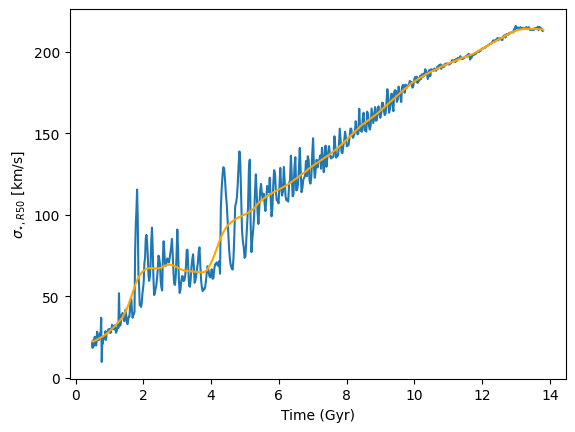

In [300]:
# stellar_disps_smooth = savgol_filter(
#     stellar_disps,
#     window_length=40,  # try 11–31 depending on noise
#     polyorder=3,
# )


stellar_disps_smooth = gaussian_filter1d(
    stellar_disps,
    sigma=10,  # increase to 8–10 for even smoother
)

plt.plot(all_times[snap_lst], stellar_disps)
plt.plot(all_times[snap_lst], stellar_disps_smooth, c="orange")

plt.xlabel("Time (Gyr)")
# plt.ylabel(r"stellar velocity dispersion (standard deviation) at R_50 [km/s]")
plt.ylabel(r"$\sigma_{\star, R50}$ [km/s]", fontsize=10)

Text(0, 0.5, '$log stellar density (R50)')

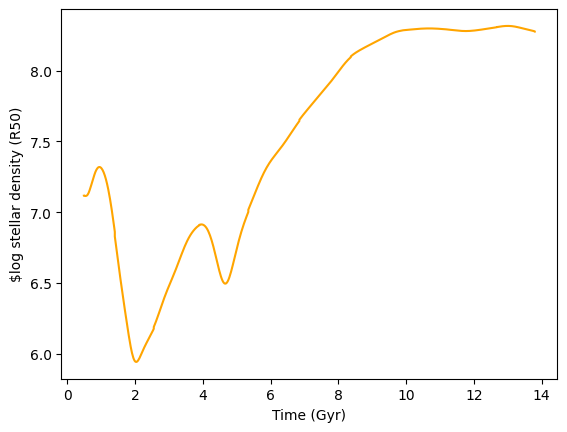

In [301]:
# stellar_disps_smooth = savgol_filter(
#     stellar_disps,
#     window_length=40,  # try 11–31 depending on noise
#     polyorder=3,
# )


stellar_dens_smooth = gaussian_filter1d(
    stellar_dens,
    sigma=10,  # increase to 8–10 for even smoother
)

# plt.plot(all_times[snap_lst], stellar_dens)
# plt.plot(all_times[snap_lst], stellar_dens_smooth, c="orange")
plt.plot(all_times[snap_lst], np.log10(stellar_dens_smooth), c="orange")

plt.xlabel("Time (Gyr)")
# plt.ylabel(r"stellar velocity dispersion (standard deviation) at R_50 [km/s]")
plt.ylabel(r"$log stellar density (R50)", fontsize=10)
# plt.yscale("log")

Text(0, 0.5, '$\\gamma\\;[\\mathrm{Gyr}^{-1}]$')

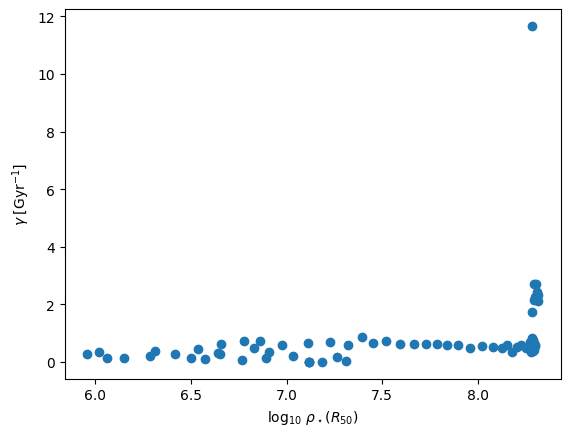

In [302]:
tims = all_times[snap_lst]

ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
ghost_data = h5py.File(ghost_file, "r")

src_dat = ghost_data["it001"]["source"]
in_msk = src_dat["grpid"][()] == 0

tfor = src_dat["tfor"][in_msk]  # formation times
tdis = src_dat["tdis"][in_msk]  # disruption times

# Keep only clusters that actually disrupt
valid = tdis > 0
tfor = tfor[valid]
tdis = tdis[valid]


dt = 0.2  # Gyr
time_bins = np.arange(0, 13.8 + dt, dt)

N_dis, bin_edges = np.histogram(tdis, bins=time_bins)
t_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

Gamma = N_dis / dt  # clusters per Gyr

N_alive = np.array([np.sum((tfor <= t) & (tdis > t)) for t in t_centers])


gamma = np.zeros_like(Gamma)
mask = N_alive > 0
gamma[mask] = Gamma[mask] / N_alive[mask]  # fraction per Gyr


stellar_dens_at_tc = np.interp(t_centers, tims, stellar_dens_smooth)

plt.scatter(np.log10(stellar_dens_at_tc), gamma)
plt.xlabel(r"$\log_{10}\,\rho_\star(R_{50})$")
plt.ylabel(r"$\gamma\;[\mathrm{Gyr}^{-1}]$")

/var/folders/nb/byfjq48d6jz8b3g74s3zr7rh0000gp/T/ipykernel_12547/250954978.py:32: RuntimeWarning: invalid value encountered in divide
  Gamma = N_dis / dt_snap


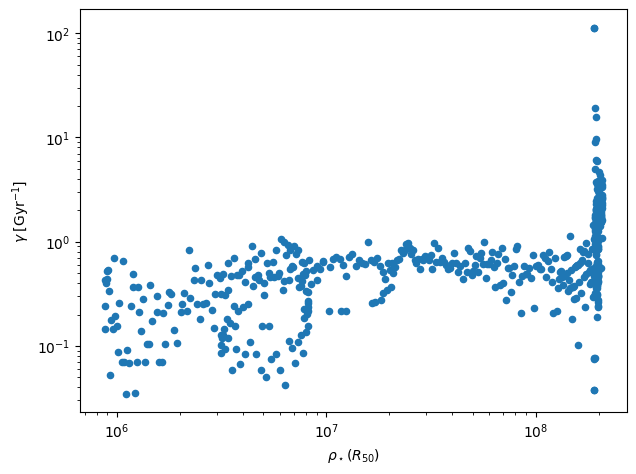

In [303]:
# --- Snapshot times ---
tims = np.asarray(all_times[snap_lst])  # shape (N_snap,)

# --- Load ghost data ---
ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
ghost_data = h5py.File(ghost_file, "r")

src_dat = ghost_data["it001"]["source"]
in_msk = src_dat["grpid"][()] == 0

tfor = src_dat["tfor"][in_msk]  # formation times (Gyr)
tdis = src_dat["tdis"][in_msk]  # disruption times (Gyr)

# Keep only clusters that actually disrupt
valid = tdis > 0
tfor = tfor[valid]
tdis = tdis[valid]

# --- Use snapshot times as bins ---
time_bins = tims  # snapshot-aligned bins

# Number of disruptions per snapshot interval
N_dis, _ = np.histogram(tdis, bins=time_bins)

# Time step between snapshots
dt_snap = np.diff(time_bins)  # shape (N_snap-1,)

# Midpoints of snapshot intervals
t_centers = 0.5 * (time_bins[:-1] + time_bins[1:])

# Absolute disruption rate (clusters / Gyr)
Gamma = N_dis / dt_snap

# Number of clusters alive at each interval
N_alive = np.array([np.sum((tfor <= t) & (tdis > t)) for t in t_centers])

# Specific disruption rate (fraction per Gyr)
gamma = np.zeros_like(Gamma)
mask = N_alive > 0
gamma[mask] = Gamma[mask] / N_alive[mask]

# --- Plot against snapshot-based stellar density ---
plt.scatter(stellar_dens_smooth[:-1][mask], gamma[mask], s=20)

plt.xlabel(r"$\rho_\star(R_{50})$")
plt.ylabel(r"$\gamma\;[\mathrm{Gyr}^{-1}]$")
plt.tight_layout()

plt.xscale("log")
plt.yscale("log")


Text(0, 0.5, 'Number of GCs disrupted')

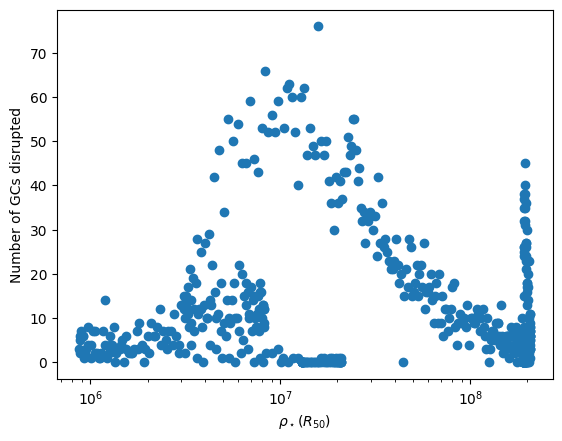

In [304]:
plt.scatter(stellar_dens_smooth[:-1], N_dis)
plt.xscale("log")
plt.xlabel(r"$\rho_\star(R_{50})$")
plt.ylabel("Number of GCs disrupted")

In [309]:
hals[600].prop("star.velocity")[0]

array([nan, nan, nan], dtype=float32)